In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [2]:
df = load_diabetes(as_frame=True).frame

In [3]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
x = df.drop(columns = ["target"])
y = df["target"]

In [6]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

In [7]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(x_train , y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [8]:
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

In [10]:
from sklearn.metrics import r2_score , mean_squared_error

print("MSE train ", mean_squared_error(y_train , y_pred_train))
print("MSE test ", mean_squared_error(y_test , y_pred_test))

print("r2 train ", r2_score(y_train , y_pred_train))
print("r2 test ", r2_score(y_test , y_pred_test))

MSE train  0.0
MSE test  4885.76404494382
r2 train  1.0
r2 test  0.07783614421543195


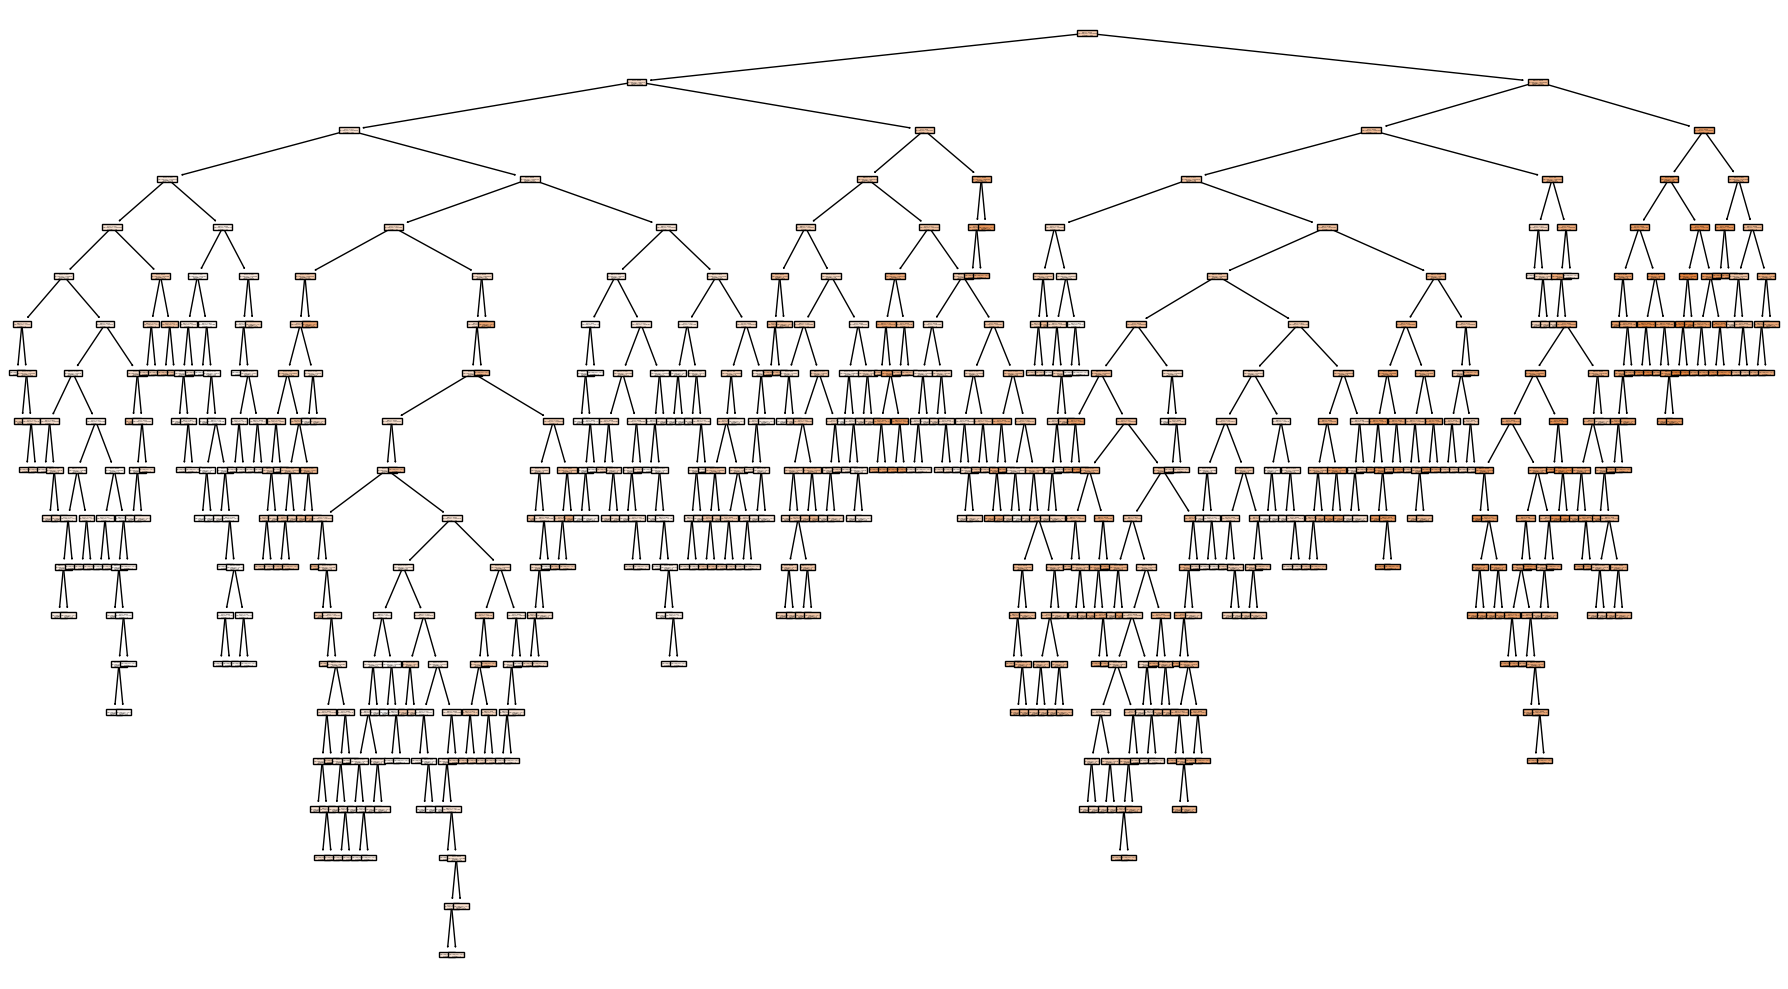

In [11]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18 , 10))
plot_tree(
    model,
    feature_names=x.columns,
    filled=True
)
plt.tight_layout()
plt.show()

# Random Foresr Regressor

In [12]:
from sklearn.ensemble import RandomForestRegressor

In [13]:
rf = RandomForestRegressor(
    n_estimators=201,
    oob_score=True
)

rf.fit(x_train , y_train)

C:\Users\admin\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)


,n_estimators,201
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [14]:
y_pred = rf.predict(x_test)

In [16]:
print("OOB Score : ", rf.oob_score_)
print("Testing accuracy : ", r2_score(y_test , y_pred))

OOB Score :  0.4421555288733534
Testing accuracy :  0.44771220718618676
